# Prueba del modelo de regresion sobre los nuevos datos

In [1]:
from modelos.utils.metricas import evaluar_regresion
from sklearn.metrics import PredictionErrorDisplay
from extraccion import minioFunctions as mf
import pandas as pd

In [2]:
cliente = mf.crear_cliente()

df = mf.bajar_fichero(cliente, path_server='grupo3/cleaned/incendios_2026.parquet')
modelo = mf.bajar_fichero(cliente, path_server='grupo3/modelo_xgboost_frp.pkl', type='pkl')
if df is None:
    raise RuntimeError("fallo en la descarga del dataset desde MinIO")
if modelo is None:
    raise RuntimeError("fallo en la descarga del modelo. Verifica credenciales y la red")

print('MODELO PROBADO SOBRE NUEVOS DATOS')
target_col = 'frp_mean'
X = df[modelo.feature_names_in_]
y = df[target_col]
y_pred_test = modelo.predict(X)
metricas_test = evaluar_regresion(y, y_pred_test, "Test — XGBoost Regressor", en_log=False)
features = {'original':y, 'predicho':y_pred_test}
salida = pd.DataFrame(features)
print('\nCOMPARATIVA ESTADISTICA ENTRE ORIGINAL Y LO PREDICHO')
print(salida.describe())

Dataframe incendios_2026.parquet importado correctamente
pkl modelo_xgboost_frp.pkl importado correctamente
MODELO PROBADO SOBRE NUEVOS DATOS

── Métricas Test — XGBoost Regressor ──────────────────────────────
  RMSE (principal): 30.0698
  MAE             : 22.6971
  R²              : -0.1296

COMPARATIVA ESTADISTICA ENTRE ORIGINAL Y LO PREDICHO
         original   predicho
count   22.000000  22.000000
mean    83.134773  77.853889
std     28.958415   6.524822
min     50.690000  66.859528
25%     62.125000  73.358515
50%     73.770000  77.732845
75%     97.986250  81.239313
max    148.100000  93.938667


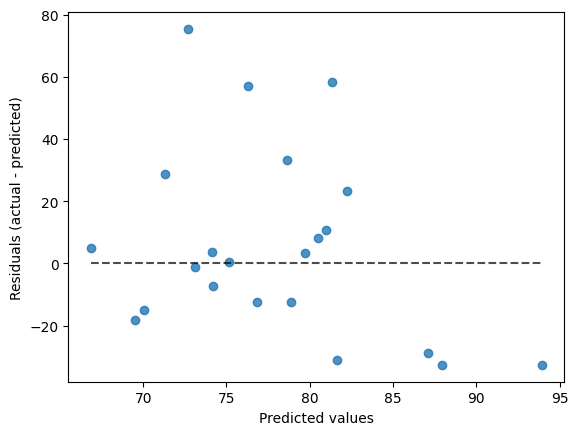

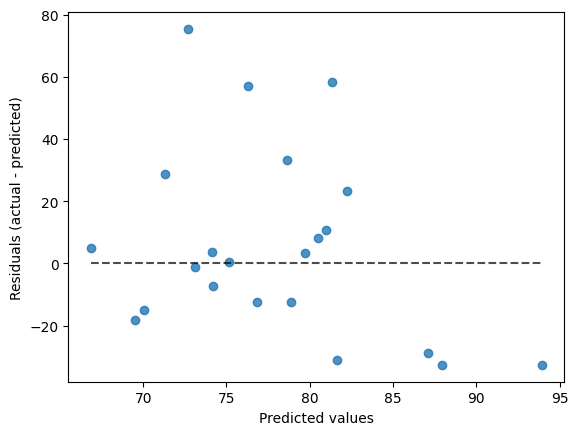

In [ ]:
error_disp = PredictionErrorDisplay.from_estimator(modelo, X, y)
error_disp.plot()